In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Data Loading with Augmentation

In [2]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),       # mirrors help clothing classes
    transforms.RandomCrop(28, padding=4),          # shift invariance
    transforms.RandomRotation(degrees=10),         # slight rotation robustness
    transforms.ColorJitter(brightness=0.2,
                           contrast=0.2),          # lighting variation
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))    # FashionMNIST mean/std
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

trainset_full = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/',
                                       download=True, train=True,
                                       transform=train_transform)

train_idx, val_idx = train_test_split(
    list(range(len(trainset_full))),
    test_size=0.1,           # 10% val (smaller = more training data)
    random_state=42,
    stratify=trainset_full.targets
)

train_set   = torch.utils.data.Subset(trainset_full, train_idx)

valset_full = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/',
                                     download=False, train=True,
                                     transform=eval_transform)
val_set = torch.utils.data.Subset(valset_full, val_idx)

testset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/',
                                 download=False, train=False,
                                 transform=eval_transform)

BATCH_SIZE = 128

trainloader = torch.utils.data.DataLoader(
    train_set, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True
)
validationloader = torch.utils.data.DataLoader(
    val_set, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True
)

print(f'Train samples    : {len(train_set)}')
print(f'Validation samples: {len(val_set)}')
print(f'Test samples     : {len(testset)}')

100%|██████████| 26.4M/26.4M [00:01<00:00, 19.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 305kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.62MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.3MB/s]


Train samples    : 54000
Validation samples: 6000
Test samples     : 10000


## 3. Model Architecture

```
Input (1×28×28)
     │
     ├──── CNN Branch ─────────────────────────────────────────┐
     │     Conv(1→32) → BN → ReLU                             │
     │     ResBlock(32→64, stride=2)  → 14×14                 │
     │     ResBlock(64→128, stride=2) →  7×7                  │
     │     ResBlock(128→256, stride=2) →  4×4                 │
     │     GlobalAvgPool → Flatten → FC(256→512) → 512-D      │
     │                                                         │
     └──── FNN Branch ─────────────────────────────────────────┤
           Flatten(784)                                        │
           FC(784→512) → BN → ReLU → Dropout(0.4)            │
           FC(512→256) → BN → ReLU → Dropout(0.3)            │
           FC(256→128) → BN → ReLU → 128-D                   │
                                                               │
     Concat [512 + 128 = 640-D] ◄──────────────────────────────┘
     FC(640→256) → BN → ReLU → Dropout(0.3)
     FC(256→10)
```

In [3]:
class ResBlock(nn.Module):
    """A basic residual block: Conv→BN→ReLU→Conv→BN, with a skip connection.
    If in_channels != out_channels or stride>1, the skip branch uses a 1×1 conv.
    """
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels,
                               kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels,
                               kernel_size=3, stride=1,
                               padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)

        # skip connection when dims change
        self.skip = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.skip = nn.Sequential(
                nn.Conv2d(in_channels, out_channels,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.skip(x)   # residual addition
        return F.relu(out)


class CNNBranch(nn.Module):
    """Extracts local spatial features from the 2-D image."""
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )
        self.layer1 = ResBlock(32,  64,  stride=2)   # 28→14
        self.layer2 = ResBlock(64,  128, stride=2)   # 14→7
        self.layer3 = ResBlock(128, 256, stride=2)   #  7→4

        self.gap = nn.AdaptiveAvgPool2d(1)            # Global Avg Pool → 256
        self.fc  = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.gap(x)
        return self.fc(x)   # (B, 512)


class FNNBranch(nn.Module):
    """Extracts global statistical features from the flattened pixel vector."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)   # (B, 128)


class CNNFNNFusionModel(nn.Module):
    """Concatenates CNN and FNN features, then classifies."""
    def __init__(self):
        super().__init__()
        self.cnn_branch = CNNBranch()   # → 512-D
        self.fnn_branch = FNNBranch()   # → 128-D

        fused_dim = 512 + 128           # 640
        self.fusion_head = nn.Sequential(
            nn.Linear(fused_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        cnn_feat = self.cnn_branch(x)           # (B, 512)
        fnn_feat = self.fnn_branch(x)           # (B, 128)
        fused    = torch.cat([cnn_feat, fnn_feat], dim=1)  # (B, 640)
        return self.fusion_head(fused)          # (B, 10)  — raw logits


model = CNNFNNFusionModel().to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total_params:,}')
print(model)

Total trainable parameters: 2,074,986
CNNFNNFusionModel(
  (cnn_branch): CNNBranch(
    (stem): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (layer1): ResBlock(
      (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (skip): Sequential(
        (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(2, 2), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (layer2): ResBlock(
      (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2,

## 4. Loss, Optimizer, Scheduler

In [4]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4     # L2 regularisation
)

EPOCHS       = 80
scheduler    = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

PATIENCE     = 15
best_val_acc = 0.0
es_counter   = 0

## 5. Training Loop

In [5]:
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

def run_epoch(loader, train=True):
    """Run one epoch; returns (avg_loss, accuracy)."""
    if train:
        model.train()
    else:
        model.eval()

    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            if train:
                optimizer.zero_grad()

            logits = model(images)
            loss   = criterion(logits, labels)

            if train:
                loss.backward()
                # Gradient clipping prevents exploding gradients
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            preds       = logits.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += images.size(0)

    return total_loss / total, correct / total


print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | "
      f"{'Val Loss':>8} | {'Val Acc':>7} | {'LR':>8}")
print('-' * 65)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(trainloader, train=True)
    vl_loss, vl_acc = run_epoch(validationloader, train=False)
    scheduler.step()

    train_losses.append(tr_loss);  val_losses.append(vl_loss)
    train_accs.append(tr_acc);     val_accs.append(vl_acc)

    current_lr = scheduler.get_last_lr()[0]
    print(f"{epoch:>5} | {tr_loss:>10.4f} | {tr_acc:>8.4f}% | "
          f"{vl_loss:>8.4f} | {vl_acc:>7.4f} | {current_lr:.2e}")

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        es_counter   = 0
        torch.save(model.state_dict(), 'best_fusion_model.pth')
        print(f"  ✔ New best val acc: {best_val_acc:.4f} — model saved")
    else:
        es_counter += 1
        if es_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}. Best val acc: {best_val_acc:.4f}")
            break

model.load_state_dict(torch.load('best_fusion_model.pth'))
print(f"\nTraining complete. Best validation accuracy: {best_val_acc:.4f}")

Epoch | Train Loss | Train Acc | Val Loss | Val Acc |       LR
-----------------------------------------------------------------
    1 |     1.0457 |   0.7492% |   0.8820 |  0.8252 | 1.00e-03
  ✔ New best val acc: 0.8252 — model saved
    2 |     0.8875 |   0.8258% |   0.7932 |  0.8643 | 9.98e-04
  ✔ New best val acc: 0.8643 — model saved
    3 |     0.8456 |   0.8466% |   0.8031 |  0.8590 | 9.97e-04
    4 |     0.8211 |   0.8569% |   0.7935 |  0.8653 | 9.94e-04
  ✔ New best val acc: 0.8653 — model saved
    5 |     0.8048 |   0.8644% |   0.7614 |  0.8775 | 9.90e-04
  ✔ New best val acc: 0.8775 — model saved
    6 |     0.7939 |   0.8691% |   0.7079 |  0.9058 | 9.86e-04
  ✔ New best val acc: 0.9058 — model saved
    7 |     0.7830 |   0.8749% |   0.7425 |  0.8860 | 9.81e-04
    8 |     0.7749 |   0.8787% |   0.7178 |  0.8988 | 9.76e-04
    9 |     0.7684 |   0.8816% |   0.6992 |  0.9085 | 9.69e-04
  ✔ New best val acc: 0.9085 — model saved
   10 |     0.7604 |   0.8856% |   0.7140 |  0

## 6. Test Evaluation

In [6]:
test_loss, test_acc = run_epoch(testloader, train=False)
print(f'Test Loss    : {test_loss:.4f}')
print(f'Test Accuracy: {test_acc * 100:.2f}%')

Test Loss    : 0.6259
Test Accuracy: 94.40%


## 7. Training Curves

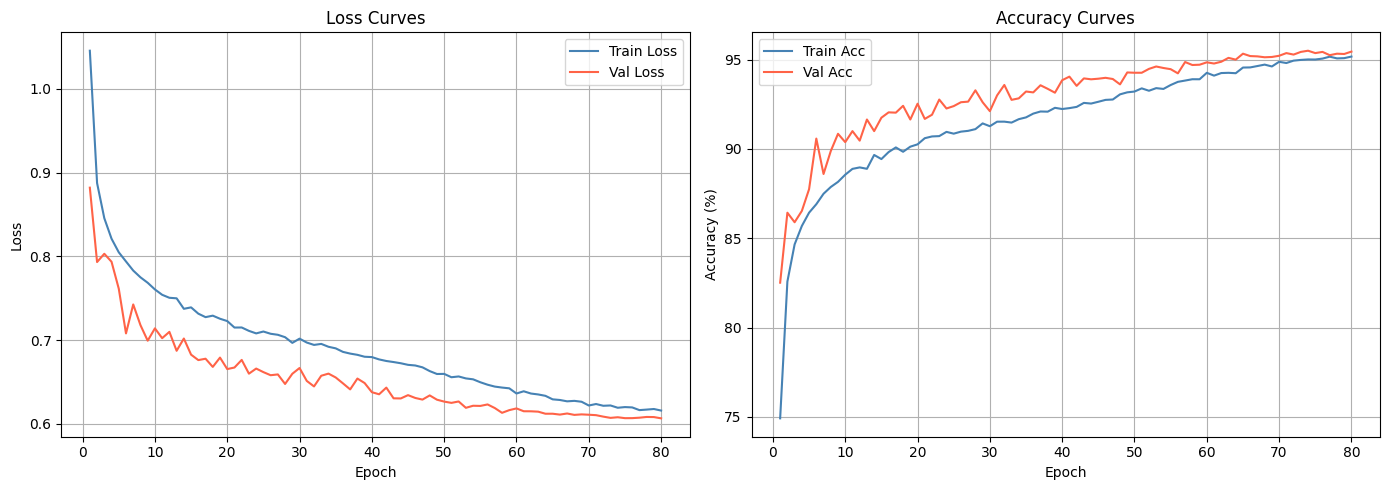

Final Test Accuracy: 94.40%


In [7]:
epochs_ran = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs_ran, train_losses, label='Train Loss', color='steelblue')
axes[0].plot(epochs_ran, val_losses,   label='Val Loss',   color='tomato')
axes[0].set_title('Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(epochs_ran, [a * 100 for a in train_accs], label='Train Acc', color='steelblue')
axes[1].plot(epochs_ran, [a * 100 for a in val_accs],   label='Val Acc',   color='tomato')
# axes[1].axhline(y=97, color='green', linestyle='--', label='97% target')
axes[1].set_title('Accuracy Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print(f'Final Test Accuracy: {test_acc * 100:.2f}%')

## 8. Per-Class Accuracy

In [8]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

class_correct = [0] * 10
class_total   = [0] * 10

model.eval()
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        preds = model(images).argmax(dim=1)
        for pred, label in zip(preds, labels):
            class_correct[label] += (pred == label).item()
            class_total[label]   += 1

print(f"{'Class':<15} | {'Correct':>7} | {'Total':>5} | {'Accuracy':>8}")
print('-' * 45)
for i, name in enumerate(class_names):
    acc = 100 * class_correct[i] / class_total[i]
    print(f"{name:<15} | {class_correct[i]:>7} | {class_total[i]:>5} | {acc:>7.2f}%")

overall = 100 * sum(class_correct) / sum(class_total)
print(f"\n{'Overall':<15} | {sum(class_correct):>7} | {sum(class_total):>5} | {overall:>7.2f}%")

Class           | Correct | Total | Accuracy
---------------------------------------------
T-shirt/top     |     911 |  1000 |   91.10%
Trouser         |     992 |  1000 |   99.20%
Pullover        |     927 |  1000 |   92.70%
Dress           |     951 |  1000 |   95.10%
Coat            |     934 |  1000 |   93.40%
Sandal          |     985 |  1000 |   98.50%
Shirt           |     803 |  1000 |   80.30%
Sneaker         |     975 |  1000 |   97.50%
Bag             |     995 |  1000 |   99.50%
Ankle boot      |     967 |  1000 |   96.70%

Overall         |    9440 | 10000 |   94.40%


## 9. Visualise Predictions

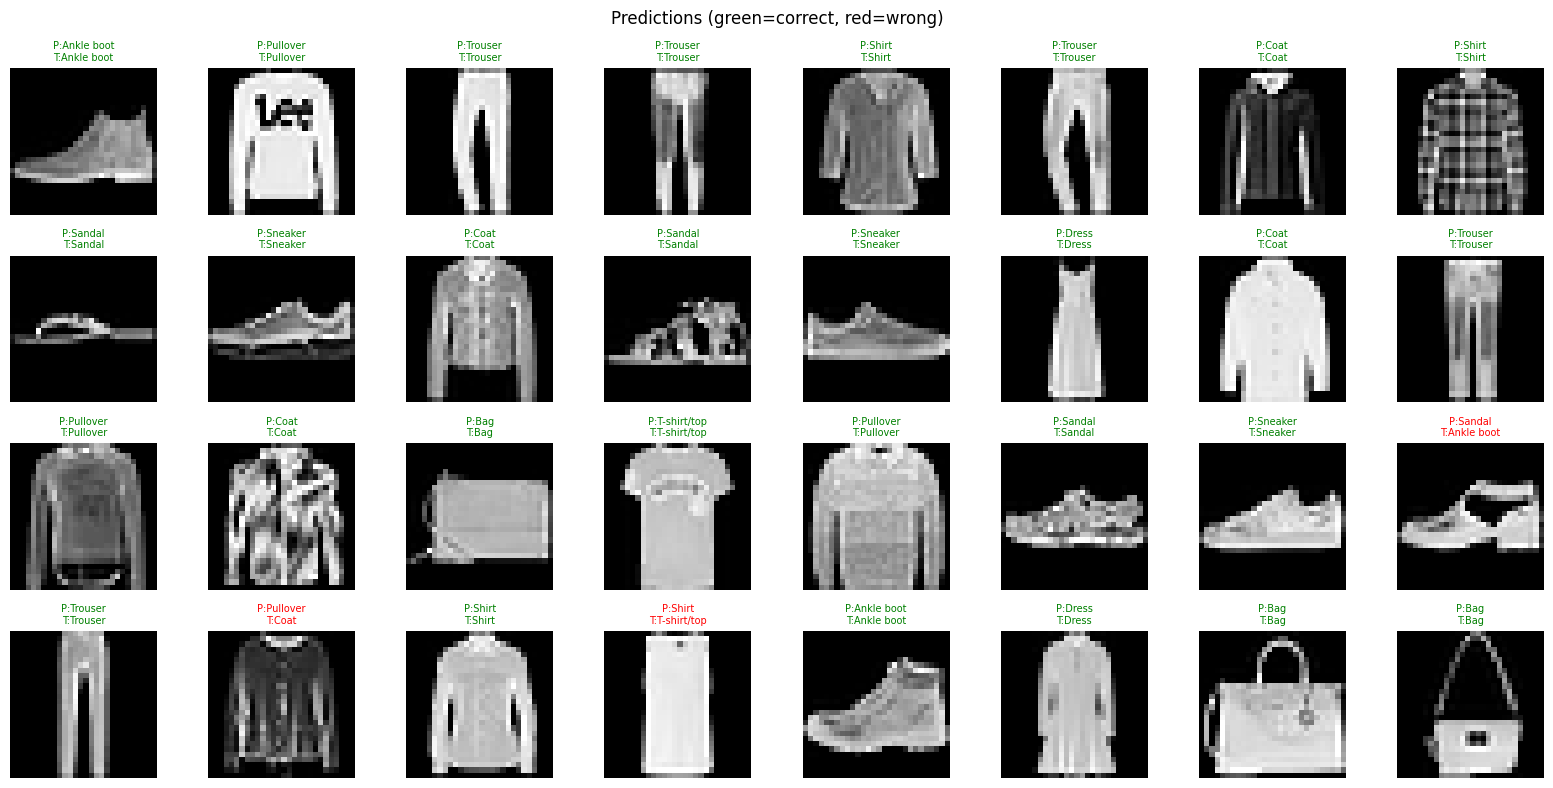

In [9]:
dataiter = iter(testloader)
images, labels = next(dataiter)
images_dev = images.to(device)

model.eval()
with torch.no_grad():
    preds = model(images_dev).argmax(dim=1).cpu()

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    img = images[i].squeeze().numpy()
    # Un-normalise for display
    img = img * 0.353 + 0.286
    img = np.clip(img, 0, 1)
    ax.imshow(img, cmap='gray')
    color = 'green' if preds[i] == labels[i] else 'red'
    ax.set_title(f'P:{class_names[preds[i]]}\nT:{class_names[labels[i]]}',
                 fontsize=7, color=color)
    ax.axis('off')

plt.suptitle('Predictions (green=correct, red=wrong)', fontsize=12)
plt.tight_layout()
plt.savefig('predictions_grid.png', dpi=150)
plt.show()

In [10]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import numpy as np

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

all_preds  = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        preds  = model(images).argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
print('Predictions collected:', len(all_preds))

Predictions collected: 10000


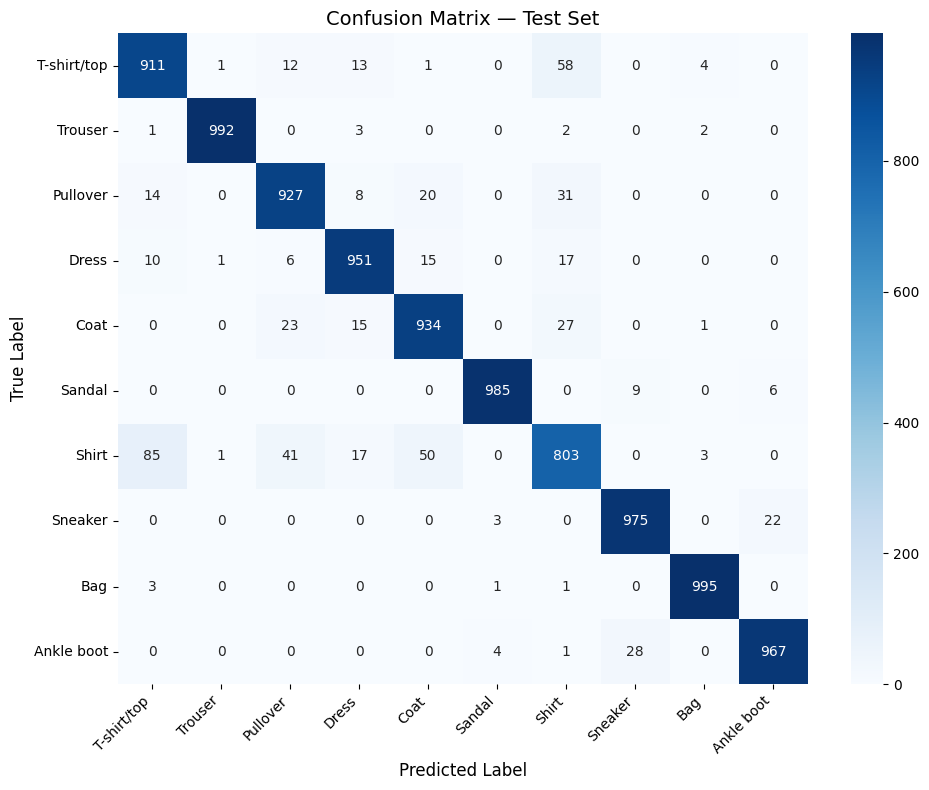

In [11]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True, fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix — Test Set', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [12]:
precision = precision_score(all_labels, all_preds, average=None)
recall    = recall_score(all_labels, all_preds, average=None)
f1        = f1_score(all_labels, all_preds, average=None)

print(f"{'Class':<15} | {'Precision':>9} | {'Recall':>6} | {'F1-Score':>8}")
print('-' * 50)
for i, name in enumerate(class_names):
    print(f"{name:<15} | {precision[i]:>9.4f} | {recall[i]:>6.4f} | {f1[i]:>8.4f}")

print('-' * 50)
print(f"{'Macro Avg':<15} | {precision.mean():>9.4f} | {recall.mean():>6.4f} | {f1.mean():>8.4f}")
print(f"{'Weighted Avg':<15} | "
      f"{precision_score(all_labels, all_preds, average='weighted'):>9.4f} | "
      f"{recall_score(all_labels, all_preds, average='weighted'):>6.4f} | "
      f"{f1_score(all_labels, all_preds, average='weighted'):>8.4f}")

Class           | Precision | Recall | F1-Score
--------------------------------------------------
T-shirt/top     |    0.8896 | 0.9110 |   0.9002
Trouser         |    0.9970 | 0.9920 |   0.9945
Pullover        |    0.9187 | 0.9270 |   0.9228
Dress           |    0.9444 | 0.9510 |   0.9477
Coat            |    0.9157 | 0.9340 |   0.9248
Sandal          |    0.9919 | 0.9850 |   0.9885
Shirt           |    0.8543 | 0.8030 |   0.8278
Sneaker         |    0.9634 | 0.9750 |   0.9692
Bag             |    0.9900 | 0.9950 |   0.9925
Ankle boot      |    0.9719 | 0.9670 |   0.9694
--------------------------------------------------
Macro Avg       |    0.9437 | 0.9440 |   0.9437
Weighted Avg    |    0.9437 | 0.9440 |   0.9437
